<a href="https://colab.research.google.com/github/williamtheodoruswijaya/semantix/blob/fel/test_run_1_deeplab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [37]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [38]:
import zipfile

zip_path = "/content/drive/MyDrive/Dal Lake Floating Plastic Waste Detection Dataset (FloPWD 2025).zip"
extract_path = "/content/data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Done unzip")

Done unzip


In [39]:
import os

for root, dirs, files in os.walk("/content/data"):
    print(root, len(files))

/content/data 0
/content/data/Dal Lake Floating Plastic Waste Detection Dataset (FloPWD 2025) 2
/content/data/Dal Lake Floating Plastic Waste Detection Dataset (FloPWD 2025)/Raw_Images 2002
/content/data/Dal Lake Floating Plastic Waste Detection Dataset (FloPWD 2025)/Segmentation_Masks 2002


In [40]:
import os, random, shutil

BASE_PATH = "/content/data/Dal Lake Floating Plastic Waste Detection Dataset (FloPWD 2025)"

image_dir = BASE_PATH + "/Raw_Images"
mask_dir = BASE_PATH + "/Segmentation_Masks"

images = sorted(os.listdir(image_dir))
random.shuffle(images)

train_split = int(0.7 * len(images))
val_split = int(0.9 * len(images))

train_imgs = images[:train_split]
val_imgs = images[train_split:val_split]

def copy_files(file_list, src_img, src_mask, dst_img, dst_mask):
    os.makedirs(dst_img, exist_ok=True)
    os.makedirs(dst_mask, exist_ok=True)

    for f in file_list:
        mask_name = os.path.splitext(f)[0] + "_mask.png"

        shutil.copy(os.path.join(src_img, f), os.path.join(dst_img, f))
        shutil.copy(os.path.join(src_mask, mask_name), os.path.join(dst_mask, mask_name))

copy_files(train_imgs, image_dir, mask_dir,
           "/content/train_images", "/content/train_masks")

copy_files(val_imgs, image_dir, mask_dir,
           "/content/val_images", "/content/val_masks")

In [41]:
import torch
# !pip install segmentation-models-pytorch
import segmentation_models_pytorch as smp
import torch
# import flash
# from flash.image import SemanticSegmentation, SemanticSegmentationData

In [42]:
from torch.utils.data import Dataset, DataLoader

In [43]:
class SegDataset(Dataset):
    def __init__(self, img_dir, mask_dir, size=256):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.files = os.listdir(img_dir)
        self.size = size

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        f = self.files[idx]

        img = Image.open(os.path.join(self.img_dir, f)).convert("RGB")
        mask_name = os.path.splitext(f)[0] + "_mask.png"
        mask = Image.open(os.path.join(self.mask_dir, mask_name))

        img = img.resize((self.size, self.size))
        mask = mask.resize((self.size, self.size))

        img = np.array(img) / 255.0
        mask = (np.array(mask) > 0).astype(np.float32)

        img = np.transpose(img, (2, 0, 1))

        return torch.tensor(img), torch.tensor(mask)

In [56]:
train_dataset = SegDataset("/content/train_images", "/content/train_masks")
val_dataset = SegDataset("/content/val_images", "/content/val_masks")

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8)

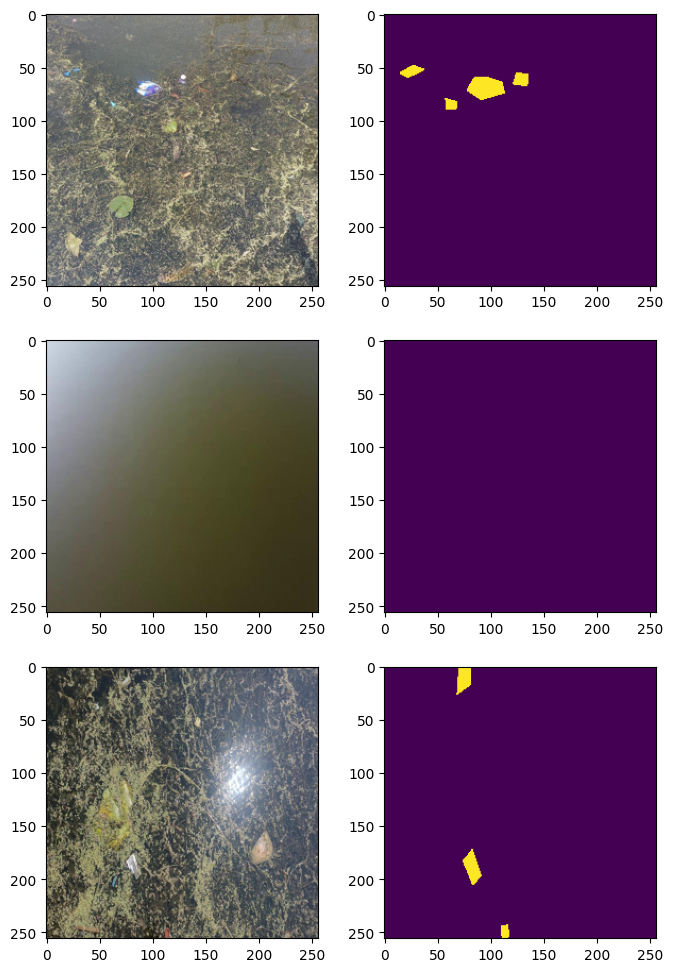

In [57]:
nb_samples = 3
fig, axarr = plt.subplots(ncols=2, nrows=nb_samples, figsize=(8, 4*nb_samples))

for imgs, masks in train_loader:
    for i in range(nb_samples):
        img = imgs[i].numpy().transpose(1,2,0)
        segm = masks[i].numpy()

        axarr[i, 0].imshow(img)
        axarr[i, 1].imshow(segm)
    break

In [58]:
model = smp.DeepLabV3Plus(
    encoder_name="mobilenet_v2",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
)

In [59]:
loss_fn = smp.losses.DiceLoss(mode='binary')
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [60]:
def iou_score(pred, target, threshold=0.5):
    pred = (pred > threshold).float()

    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection

    if union == 0:
        return 1.0

    return (intersection / union).item()

In [64]:
model.to(device)
for epoch in range(5):
    model.train()
    total_loss = 0
    total_iou = 0
    processed_batches = 0

    for imgs, masks in train_loader:
        # Skip batches with size 1 to avoid BatchNorm error when spatial dimensions are 1x1
        if imgs.shape[0] == 1:
            print(f"Skipping batch of size 1 in epoch {epoch+1}.")
            continue

        imgs = imgs.to(device).float()
        masks = masks.to(device).unsqueeze(1)

        preds = model(imgs)
        loss = loss_fn(preds, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds_sigmoid = torch.sigmoid(preds)
        total_iou += iou_score(preds_sigmoid, masks)
        processed_batches += 1

    # Ensure processed_batches is not zero to avoid division by zero
    avg_loss = total_loss / processed_batches if processed_batches > 0 else 0
    avg_iou = total_iou / processed_batches if processed_batches > 0 else 0
    print(f"Epoch {epoch+1} | Loss: {avg_loss:.4f} | IoU: {avg_iou:.4f}")

Skipping batch of size 1 in epoch 1.
Epoch 1 | Loss: 0.4448 | IoU: 0.4047
Skipping batch of size 1 in epoch 2.
Epoch 2 | Loss: 0.4412 | IoU: 0.4098
Skipping batch of size 1 in epoch 3.
Epoch 3 | Loss: 0.4212 | IoU: 0.4261
Skipping batch of size 1 in epoch 4.
Epoch 4 | Loss: 0.3991 | IoU: 0.4490
Skipping batch of size 1 in epoch 5.
Epoch 5 | Loss: 0.3832 | IoU: 0.4639


In [65]:
model.eval()
val_iou = 0

with torch.no_grad():
    for imgs, masks in val_loader:
        imgs = imgs.to(device).float()
        masks = masks.to(device).unsqueeze(1)

        preds = torch.sigmoid(model(imgs))
        val_iou += iou_score(preds, masks)

print("Validation IoU:", val_iou / len(val_loader))

Validation IoU: 0.5155207699537278


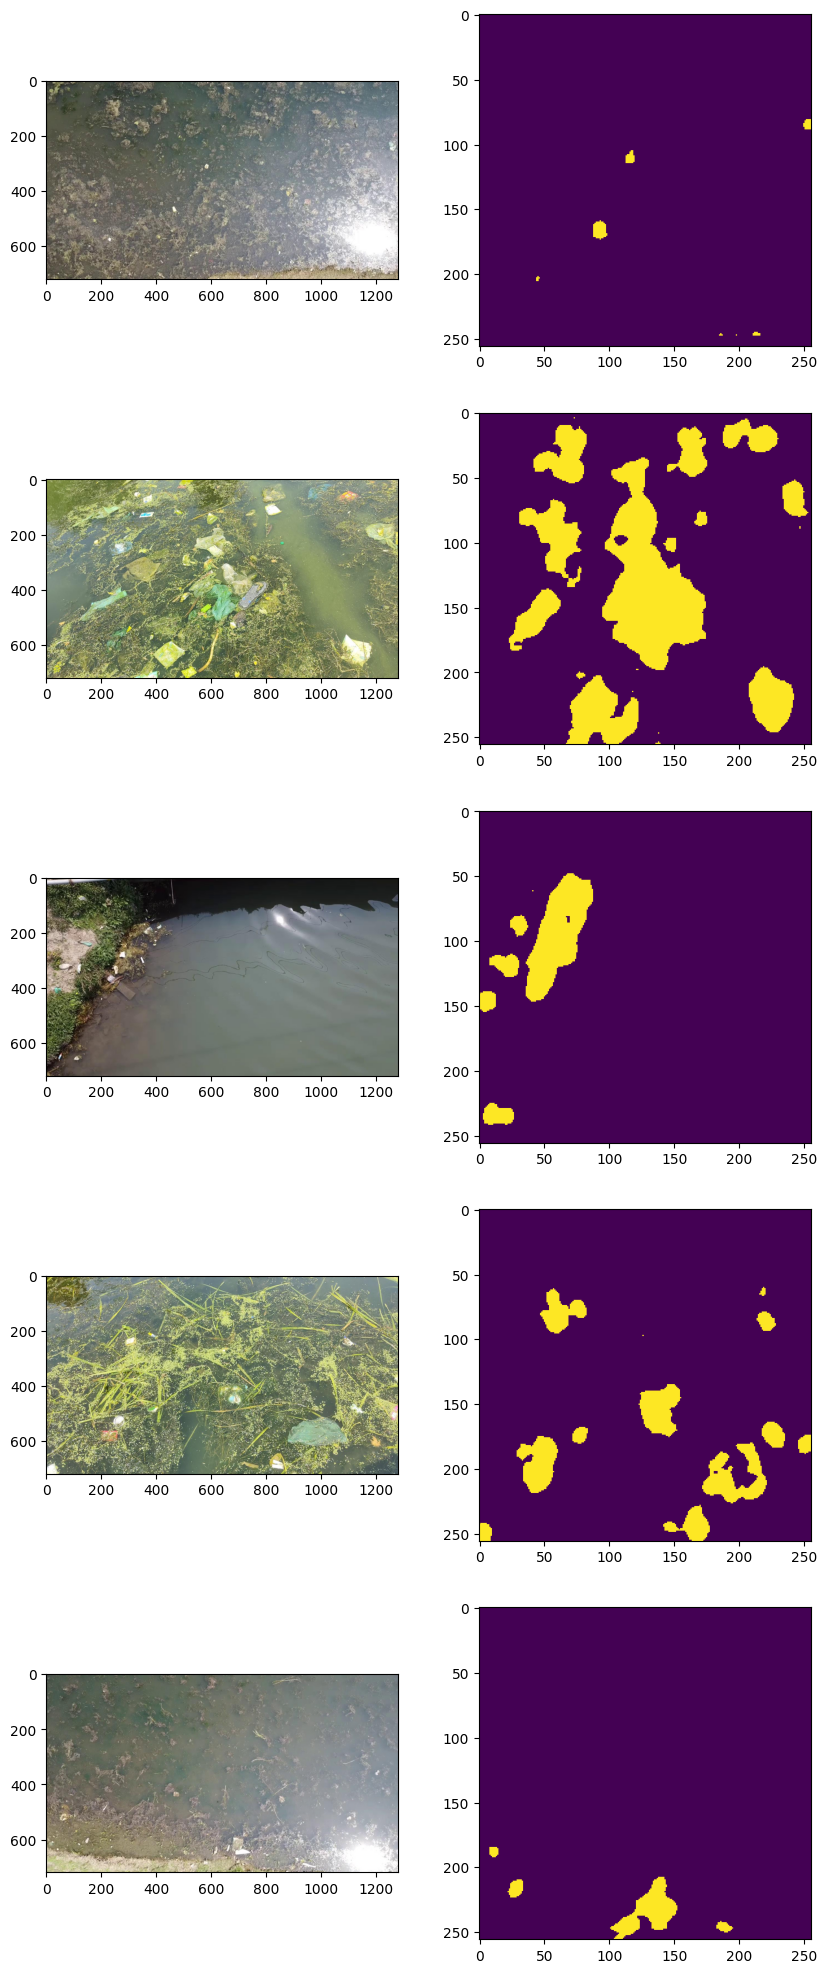

In [66]:
sample_imgs = os.listdir(image_dir)[:5]

fig, axarr = plt.subplots(ncols=2, nrows=len(sample_imgs), figsize=(10, 5 * len(sample_imgs)))

for i, f in enumerate(sample_imgs):
    img = Image.open(os.path.join(image_dir, f))

    img_resized = img.resize((256,256))

    x = np.array(img_resized) / 255.0
    x = np.transpose(x, (2,0,1))
    x = torch.tensor(x).unsqueeze(0).float().to(device)

    with torch.no_grad():
        pred = model(x)
        pred = torch.sigmoid(pred).squeeze().cpu().numpy()

    axarr[i, 0].imshow(img)
    axarr[i, 1].imshow(pred > 0.5)